# Report 2

ANTIPIN Vladislav

OUNDJIAN Milos

L'objet de ce rendu est une comparaison de deux méthodes d'apprentissage par renforcement (Q-learning et Dyna-Q avec Softmax) au vu de trois critères :
- la performance,
- l'efficacité en nombre d'échantillons d'apprentissage (sample efficiency),
- l'efficacité en temps de calcul.

Pour mener à bien cette étude :
- dotez-vous de trois labyrinthes (3x3, 5x5, 8x8) sans murs internes pour éliminer toute variabilité
- réglez au mieux les hyper-paramètres de ces deux algorithmes (avec optuna ou toute autre méthode),
- produisez deux figures d'évolution de la performance, l'une en fonction du temps de calcul et l'autre en fonction du nombre d'échantillons collectés dans l'environnement
- utilisez des tests statistiques pour déterminer si vous pouvez affirmer qu'un algorithme est meilleur que l'autre au vu de ces critères.
- énoncez vos conclusions

Ce rendu est un rapport en pdf de deux pages maximum, figures comprises, police 12pt. Tout dépassement sera sanctionné. Il devra être rédigé en LaTeX (l'utilisation d'overleaf est recommandée). Vous pouvez rédiger en anglais ou en français. L'utilisation intelligente d'outils d'aide à la rédaction est encouragée.

Vous prêterez un soin particulier aux figures, l'évaluation portera essentiellement sur la qualité de la rédaction, le respect des règles sur les figures et la rigueur des conclusions que vous énoncerez.

N'oubliez pas de faire apparaître les noms et prénoms des membres du binôme en haut de votre rapport.


In [2]:
from report02 import (
    make_mdp,
    q_learning_soft,
    dyna_q_soft,
    policy_iteration_q,
    train_models,
    plot_and_compare_auc,
    plot_and_compare_auc2,
    tune_params,
    plot_optuna
)

import numpy as np
from sklearn.metrics import auc
import optuna
from functools import partial
optuna.logging.set_verbosity(optuna.logging.WARNING)
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
%load_ext autoreload
%autoreload 2

Matplotlib backend: module://matplotlib_inline.backend_inline


# Tune hyperparameters

In [3]:
CENSOR_TIME = 0.05 
MAX_EPISODES_Q = 1000
NB_STEPS_DYNA = 6000
MDP_SIZES= ( (3,3), (5,5), (8,8) )


## Q-learning

In [17]:
mdp, env = make_mdp(2,2)
mdp.unwrapped.gamma

0.9

In [ ]:
def objective(trial, mdp):

    alpha = trial.suggest_float('alpha', 0.01, 1.1)
    beta = trial.suggest_float('beta', 0.1, 10.) 
    
    log = q_learning_soft(mdp, alpha = alpha, beta = beta, nb_episodes=MAX_EPISODES_Q, render=False)
    perfs, times, samples = log[0], log[1], log[2]
    grid = np.linspace(0, CENSOR_TIME, 100)
    interp = np.interp(grid, times, perfs)
    return auc(grid, interp)


for mdp_size in MDP_SIZES:
    mdp, env = make_mdp(*mdp_size)
    print("MDP Size:", mdp_size)
    search_space = {'alpha': np.linspace(0.01, 1.0, 10), 'beta': np.linspace(0.1, 10., 10)} 
    study_grid_analyse = tune_params(partial(objective, mdp=mdp), search_space)

MDP Size: (3, 3)


  0%|          | 0/100 [00:00<?, ?it/s]

The best parameters founded using Grid search are:  {'alpha': 1.0, 'beta': 3.4000000000000004} 


MDP Size: (5, 5)


  0%|          | 0/100 [00:00<?, ?it/s]

The best parameters founded using Grid search are:  {'alpha': 1.0, 'beta': 4.5} 


MDP Size: (8, 8)


  0%|          | 0/100 [00:00<?, ?it/s]

The best parameters founded using Grid search are:  {'alpha': 1.0, 'beta': 3.4000000000000004} 




In [171]:
# plot_optuna(study_grid_analyse, "alpha", "beta")

## Dyna-Q

In [ ]:
def objective(trial, mdp):
    alpha = trial.suggest_float('alpha', 0.01, 1.1)
    beta = trial.suggest_float('beta', 0.1, 10.) 
    nb_updates = trial.suggest_int('nb_updates', 1, 15)
    
    log = dyna_q_soft(mdp,alpha,beta, nb_steps=NB_STEPS_DYNA, nb_updates=nb_updates)
    perfs, times, samples = log[0], log[1], log[2]
    grid = np.linspace(0, CENSOR_TIME, 100)
    interp = np.interp(grid, times, perfs)
    return auc(grid, interp)

for mdp_size in MDP_SIZES:
    mdp, env = make_mdp(*mdp_size)
    print("MDP Size:", mdp_size)
    search_space = {'alpha': np.linspace(0.01, 1.0, 5), 'beta': np.linspace(0.1, 10., 5), 'nb_updates' : np.arange(1, 15, 2)} 
    study_grid_analyse = tune_params(partial(objective, mdp=mdp), search_space)

MDP Size: (3, 3)


/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/optuna/samplers/_grid.py:232: UserWarning: nb_updates contains a value with the type of <class 'numpy.int64'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  warnings.warn(message)


  0%|          | 0/175 [00:00<?, ?it/s]

The best parameters founded using Grid search are:  {'alpha': 1.0, 'beta': 5.05, 'nb_updates': 5} 


MDP Size: (5, 5)


/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/optuna/samplers/_grid.py:232: UserWarning: nb_updates contains a value with the type of <class 'numpy.int64'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  warnings.warn(message)


  0%|          | 0/175 [00:00<?, ?it/s]

The best parameters founded using Grid search are:  {'alpha': 1.0, 'beta': 5.05, 'nb_updates': 3} 


MDP Size: (8, 8)


/Users/vlad/miniconda3/envs/bbrl_env/lib/python3.10/site-packages/optuna/samplers/_grid.py:232: UserWarning: nb_updates contains a value with the type of <class 'numpy.int64'>, which is not supported by `GridSampler`. Please make sure a value is `str`, `int`, `float`, `bool` or `None` for persistent storage.
  warnings.warn(message)


  0%|          | 0/175 [00:00<?, ?it/s]

The best parameters founded using Grid search are:  {'alpha': 1.0, 'beta': 5.05, 'nb_updates': 3} 




In [196]:
# plot_optuna(study_grid_analyse, "alpha", "beta")

# Compare Sample & Time Efficiency

In [4]:
# COMMON
alpha = 1.
beta = 4 
# DYNA-Q
nb_updates = 4

# Repeat experiments
nb_repeats = 100

In [5]:
train_res = train_models(alpha=alpha,
                    beta=beta,
                    max_episodes=MAX_EPISODES_Q//3,
                    nb_steps=NB_STEPS_DYNA//3,
                    nb_updates=nb_updates,
                    nb_repeats=nb_repeats,
                    mdp_sizes =MDP_SIZES)

100%|██████████| 100/100 [02:24<00:00,  1.44s/it]


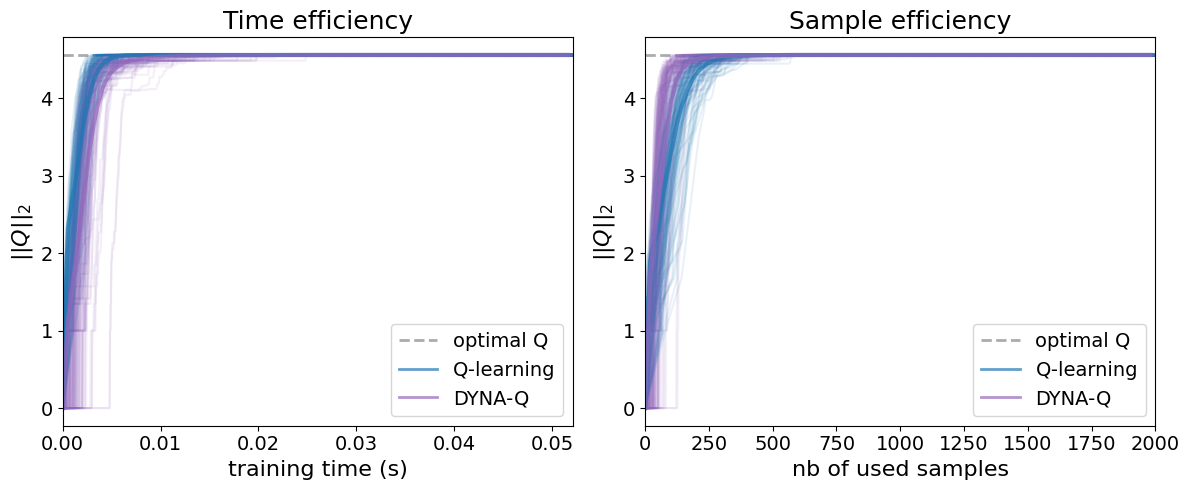

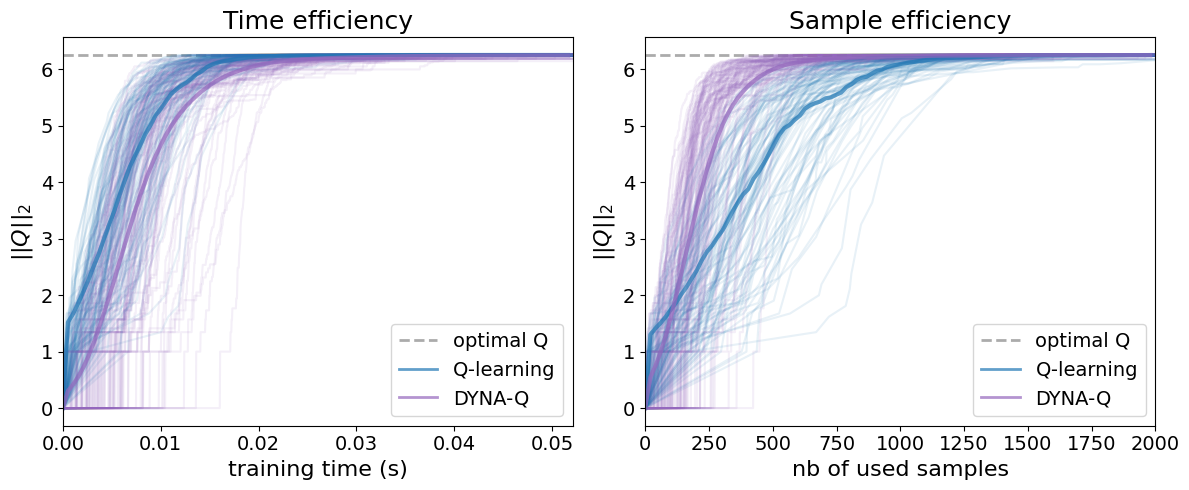

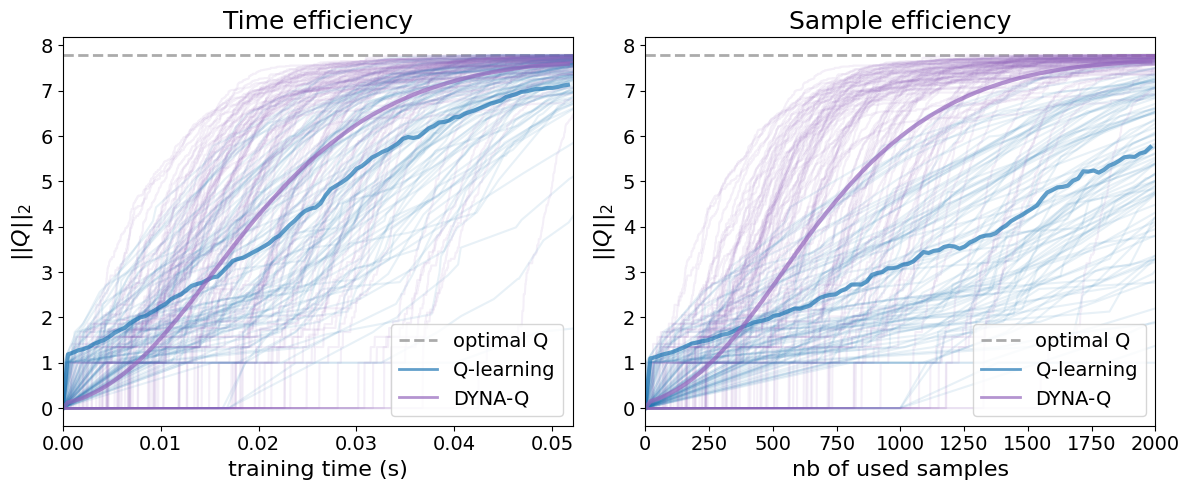

pval_ql01=np.float64(8.651425975816983e-44)
pval_ql12=np.float64(2.800535344089534e-45)
pval_ql02=np.float64(5.288878648425347e-52)
pval_dyna01=np.float64(9.074458148243468e-37)
pval_dyna12=np.float64(3.214900785968063e-28)
pval_dyna02=np.float64(1.0494797123206724e-40)
pval_ql01=np.float64(2.19932192338129e-43)
pval_ql12=np.float64(5.491855830727945e-55)
pval_ql02=np.float64(9.21297708533477e-62)
pval_dyna01=np.float64(8.807948969346037e-38)
pval_dyna12=np.float64(5.64078295789525e-32)
pval_dyna02=np.float64(1.3847802223705837e-40)


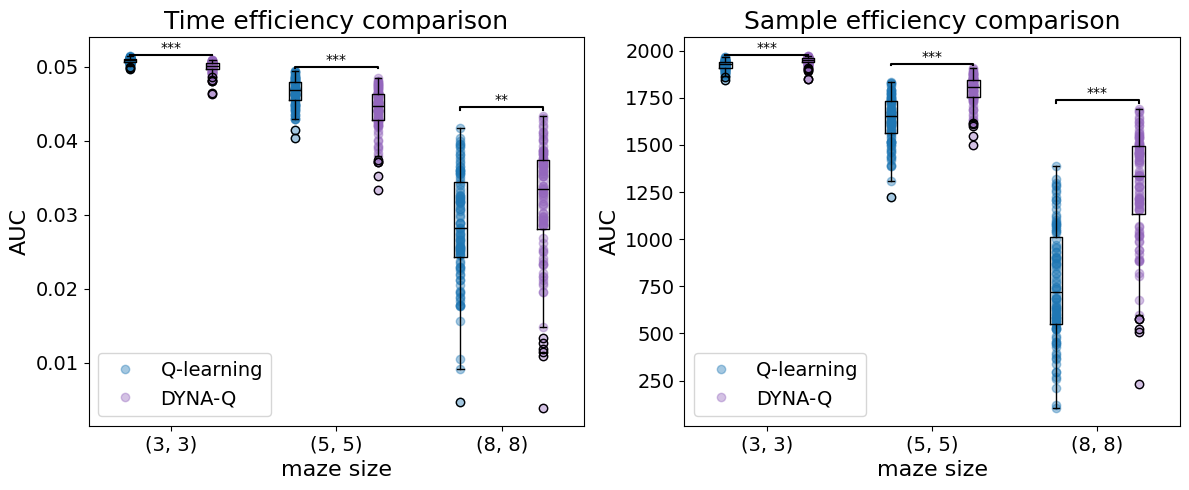

In [23]:
plt.rcParams.update({
    'axes.titlesize': 18,      # Title of axes
    'axes.labelsize': 16,      # X and Y labels
    'xtick.labelsize': 14,     # X tick labels
    'ytick.labelsize': 14,     # Y tick labels
    'legend.fontsize': 14,     # Legend text
    'figure.titlesize': 20     # Figure suptitle
})
plot_and_compare_auc2(*train_res,
                        nb_repeats=nb_repeats,
                        mdp_sizes=MDP_SIZES,
                        alpha_plot = 0.1, 
                        colors = ("#888888","#1f77b4", "#9467bd") )

In [ ]:
# plot_and_compare_auc(alpha,
#                     beta,
#                     max_episodes,
#                     nb_steps,
#                     nb_updates,
#                     nb_repeats,
#                     MDP_SIZES)